C:\Users\kun\AppData\Local\Temp\ipykernel_12336\1789394402.py:59: RuntimeWarning: h does not appear to by symmetric, conversion may fail
  h_min = minimum_phase(h)


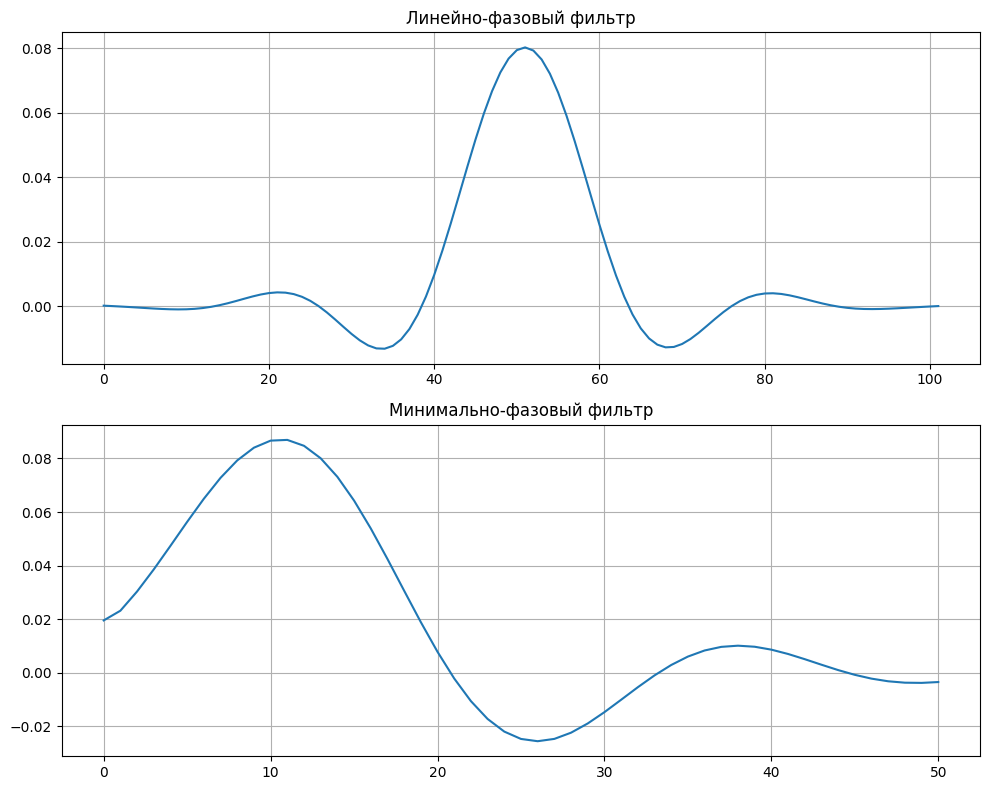

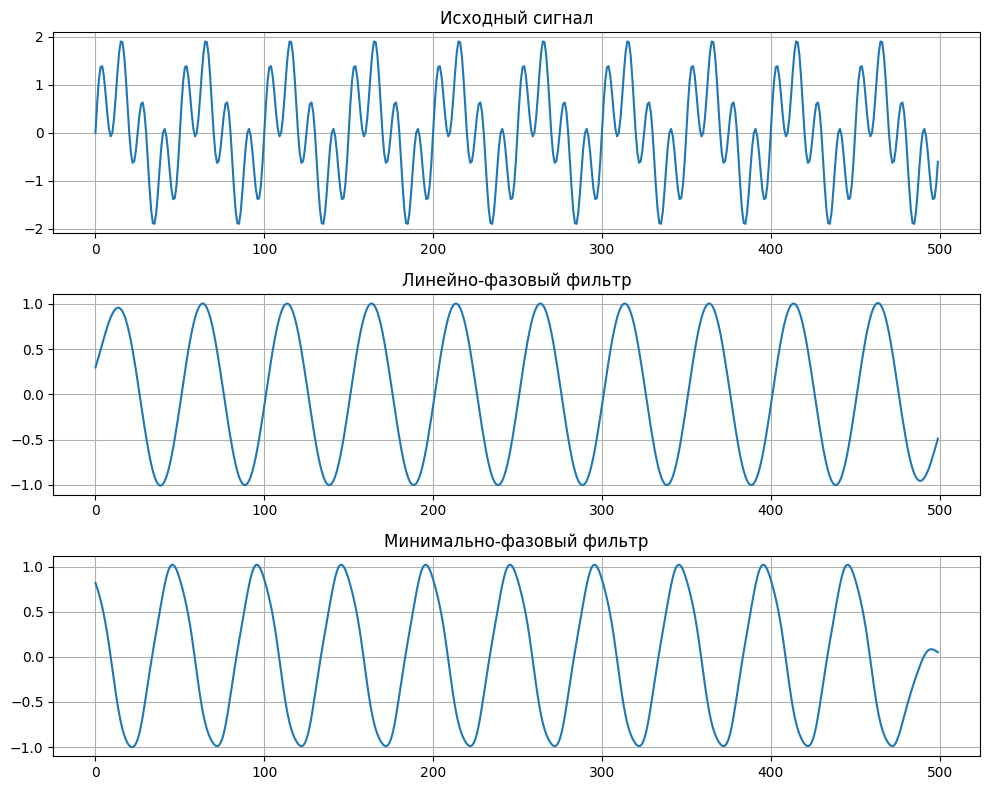

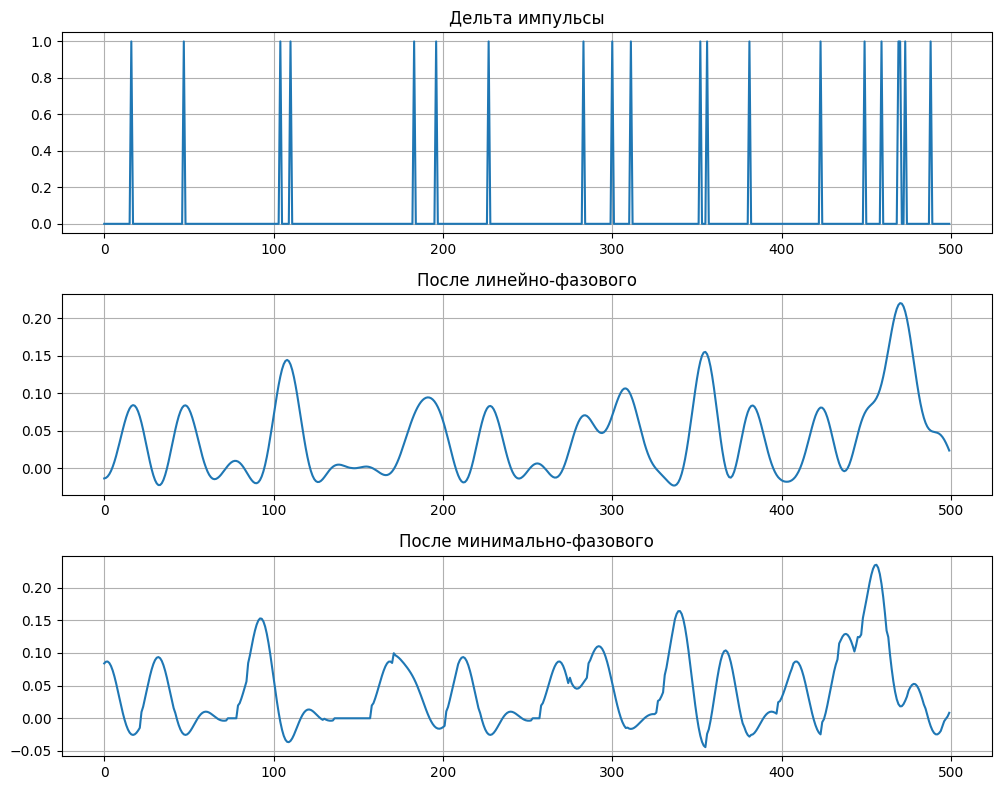

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import minimum_phase

plt.rcParams["figure.figsize"] = (10, 8)


def generate_signal(fs, T, f1, f2):
    t = np.arange(0, T, 1/fs)
    y = np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t)
    return t, y


def design_lowpass(fs, fc, M):
    n = np.arange(-M//2, M//2 + 1)
    h = 2*fc/fs * np.sinc(2*fc*n/fs)
    h *= np.hamming(len(h))
    h /= np.sum(h)
    return h


def apply_filter(x, h):
    return np.convolve(x, h, mode="same")


def generate_deltas(N, k):
    x = np.zeros(N)
    pos = np.random.choice(N, k, replace=False)
    x[pos] = 1
    return x


def plot_signals(signals, titles):
    n = len(signals)
    plt.figure()

    for i in range(n):
        plt.subplot(n,1,i+1)
        plt.plot(signals[i])
        plt.title(titles[i])
        plt.grid()

    plt.tight_layout()
    plt.show()


fs = 500
T = 1
f1 = 10
f2 = 40
fc = 20
M = 101


t, y = generate_signal(fs, T, f1, f2)

h = design_lowpass(fs, fc, M)

h_min = minimum_phase(h)


plot_signals(
    [h, h_min],
    ["Линейно-фазовый фильтр", "Минимально-фазовый фильтр"]
)


y_lin = apply_filter(y, h)
y_min = apply_filter(y, h_min)

plot_signals(
    [y, y_lin, y_min],
    ["Исходный сигнал", "Линейно-фазовый фильтр", "Минимально-фазовый фильтр"]
)


x = generate_deltas(len(y), 20)

delta_lin = apply_filter(x, h)
delta_min = apply_filter(x, h_min)

plot_signals(
    [x, delta_lin, delta_min],
    ["Дельта импульсы", "После линейно-фазового", "После минимально-фазового"]
)